In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('../../../Revenue.csv')

### 1) EDA

In [3]:
before = df[(df['session_start_dt'].str.contains("2019")) 
                   | (df['session_start_dt'].str.contains("2020-01")) 
                   | (df['session_start_dt'].str.contains("2020-02"))]
after = df[(~df['session_start_dt'].str.contains("2019")) 
                   & (~df['session_start_dt'].str.contains("2020-01")) 
                   & (~df['session_start_dt'].str.contains("2020-02"))]

In [4]:
last12 = df[(df['session_start_dt'].str.contains("2019"))]
this1 = df[(df['session_start_dt'].str.contains("2020-01"))]
this2 = df[(df['session_start_dt'].str.contains("2020-02"))]
this3 = df[(df['session_start_dt'].str.contains("2020-03"))]
this4 = df[(df['session_start_dt'].str.contains("2020-04"))]
this5 = df[(df['session_start_dt'].str.contains("2020-05"))]
this6 = df[(df['session_start_dt'].str.contains("2020-06"))]
this7 = df[(df['session_start_dt'].str.contains("2020-07"))]
this8 = df[(df['session_start_dt'].str.contains("2020-08"))]
this9 = df[(df['session_start_dt'].str.contains("2020-09"))]
this10 = df[(df['session_start_dt'].str.contains("2020-10"))]
this11 = df[(df['session_start_dt'].str.contains("2020-11"))]


([<matplotlib.axis.XTick at 0x7f807ca51e10>,
 <a list of 12 Text xticklabel objects>)

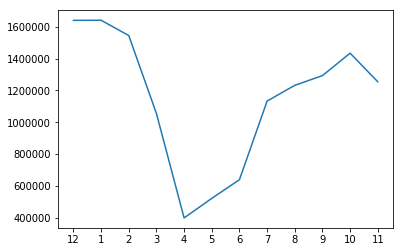

In [5]:
plt.plot([len(last12), len(this1), len(this2), len(this3), len(this4), len(this5), len(this6), len(this7), len(this8), len(this9), len(this10), len(this11)])
plt.xticks(np.arange(12), (12,1,2,3,4,5,6,7,8,9,10,11))

### 2) Demand: Time slot (per half an hour) & Covid stage

In [3]:
df['dt'] = df['session_start_dt'].apply(lambda x: datetime.strptime(x[:19], '%Y-%m-%dT%H:%M:%S'))

In [4]:
df['slot'] = df['dt'].apply(lambda x: int(x.hour) + (0.5 if int(x.minute) < 30 else 1))

In [5]:
def stage(dt):
    if dt < datetime(2020, 3, 15): 
        return 0 # before
    elif (dt >= datetime(2020, 3, 15)) & (dt < datetime(2020,5, 17)):
        return 1 # shutdown
    elif (dt >= datetime(2020, 5, 17)) & (dt < datetime(2020,7, 17)):
        return 2 # reopen 
    elif (dt >= datetime(2020, 7, 17)) & (dt < datetime(2020, 9, 30)):
        return 3 # closed_due_to_state_re
    elif (dt >= datetime(2020, 9, 30)) & (dt < datetime(2020, 10, 20)):
        return 4 # orange
    elif (dt >= datetime(2020, 10, 20)) & (dt < datetime(2020, 11, 13)):
        return 5 # yellow
    elif dt >= datetime(2020, 11, 13):
        return 6 # rollback

In [6]:
df['dt'] = df['session_start_dt'].apply(lambda x: datetime.strptime(x[:19], '%Y-%m-%dT%H:%M:%S'))
df['date'] = df['dt'].dt.date
df['slot'] = df['dt'].apply(lambda x: int(x.hour) * 2 + (1 if int(x.minute) < 30 else 2) - 1)
df['stage'] = df['dt'].apply(lambda x: stage(x))

In [ ]:
for_demand_date = df.groupby(['BLOCKFACE_ID','stage','date','slot']).count()['gross_paid_amt'].reset_index()
for_demand_date['count'] = for_demand_date['gross_paid_amt']

In [ ]:
for_demand = pd.DataFrame()
for_demand['mean'] = for_demand_date.groupby(['BLOCKFACE_ID','stage','slot']).mean()['count']
for_demand['std'] = for_demand_date.groupby(['BLOCKFACE_ID','stage','slot']).std()['count']
for_demand = for_demand.reset_index()

In [44]:
df_block = pd.read_csv('../../data/Meters/Meter_block.csv')

In [45]:
b = []
st = []
sl = []
for block_ in list(df_block['BLOCKFACE_ID'].unique()):
    for stage_ in range(7):
        for slot_ in range(48):
            b.append(block_)
            st.append(stage_)
            sl.append(slot_)
fakedata = {'BLOCKFACE_ID':b,
           'stage':st,
           'slot':sl,
           'mean':[0]*7*48*len(df_block['BLOCKFACE_ID'].unique()),
           'std':[0]*7*48*len(df_block['BLOCKFACE_ID'].unique())}
fakedf = pd.DataFrame(fakedata)

In [48]:
for_demand_agg = pd.concat([fakedf,for_demand[['BLOCKFACE_ID','stage','slot', 'mean','std']]])
for_demand_agg = for_demand_agg.groupby(['BLOCKFACE_ID', 'stage', 'slot']).sum()
for_demand_agg['std'] = for_demand_agg['std'].clip(lower=0.01)
for_demand_agg = for_demand_agg.reset_index().sort_values(['BLOCKFACE_ID','stage','slot'])

In [50]:
for_demand_agg.head()

,BLOCKFACE_ID,stage,slot,mean,std
0,0,0,0,0.0,0.01
1,0,0,1,0.0,0.01
2,0,0,2,0.0,0.01
3,0,0,3,0.0,0.01
4,0,0,4,0.0,0.01


In [49]:
for_demand_agg.describe()

,BLOCKFACE_ID,stage,slot,mean,std
count,849408.000000,849408.000000,849408.000000,849408.000000,849408.000000
mean,459420.835047,3.000000,23.500000,0.708041,0.321896
std,188077.862768,2.000001,13.853407,1.039012,0.561257
min,0.000000,0.000000,0.000000,0.000000,0.010000
25%,336111.750000,1.000000,11.750000,0.000000,0.010000
50%,446021.500000,3.000000,23.500000,0.000000,0.010000
75%,606231.250000,5.000000,35.250000,1.315789,0.522233
max,878002.000000,6.000000,47.000000,18.534091,18.273713


In [52]:
for_demand_agg.to_csv('../../data/demand.csv', index=None)

### Time to park

In [7]:
df['dt_e'] = df['session_end_dt'].apply(lambda x: datetime.strptime(x[:19], '%Y-%m-%dT%H:%M:%S'))
df['time_diff'] = df['dt_e'] - df['dt']

#### 1) Naive time to park model (mean & std for each block)

In [63]:
naive_model = pd.DataFrame(df.groupby(['BLOCKFACE_ID'])['time_diff'].agg(lambda x: x.mean()))
naive_model['std'] = df.groupby(['BLOCKFACE_ID'])['time_diff'].agg(lambda x: x.std())

#### 2) Investigate the impact of ON_OFFSTREET_TYPE (on/off) [df only contains on-street parking], OSP_ID (off-street parking space)[detailed record not available], OLD_RATE_AREA (hourly rate), METER_TYPE (single 19406/multi space 2473)


In [8]:
meter = pd.read_csv('../../data/Meters/Parking_Meters_new.csv')
useful_meter_info = meter[['POST_ID', 'OLD_RATE_AREA', 'METER_TYPE']]
time_meter = df.merge(useful_meter_info, how='left', left_on='post_id', right_on='POST_ID')

In [9]:
time_meter['duration'] = time_meter['time_diff'].apply(lambda x: x.total_seconds())

Area 1: downtown ($3.5)

Area 2: surrounding downtown ($3)

Area 3: Residential neighborhood ($2)

Area 4: NEAR Fisherman's wharf (close to port 1)

Port 1,2 Fisherman's Wharf ($2.5)

Port 3,4 North Embarcadero ($2)

Port 5,6,7,8 Downtown ($3)

Port 9,10,11 South Embarcadero ($1)

In [10]:
def pricing(area):
    if area in ['Area 1']:
        return 3.5
    elif area in ['Area2', 'Port 5', 'Port 6', 'Port 7', 'Port 8']:
        return 3
    elif area in ['Area 4', 'Port 1', 'Port 2']:
        return 2.5
    elif area in ['Area 3', 'Port 3', 'Port 4']:
        return 2
    elif area in ['Port 9', 'Port 10', 'Port 11']:
        return 1
    else: 
        return 0

In [11]:
def region(area):
    if area in ['Area 1']:
        return 1 # downtown
    elif area in ['Area2']:
        return 2 # near downtown
    elif area in ['Area 3']:
        return 3 # Residential
    elif area in ['Area 4', 'Port 1', 'Port 2']:
        return 4 # Fisherman's Wharf
    elif area in ['Port 3', 'Port 4']:
        return 5 # North Embarcadero
    elif area in ['Port 5', 'Port 6', 'Port 7', 'Port 8']:
        return 6 # downtown port
    elif area in ['Port 9', 'Port 10', 'Port 11']:
        return 7 # South Embarcadero
    else:
        return 0

In [12]:
time_meter['price'] = time_meter['OLD_RATE_AREA'].apply(pricing)
time_meter['region'] = time_meter['OLD_RATE_AREA'].apply(region)

In [214]:
#time_meter.groupby('price')['time_diff'].agg(lambda x: x.mean())

In [215]:
#time_meter.groupby('region')['time_diff'].agg(lambda x: x.mean())

(0, 80000)

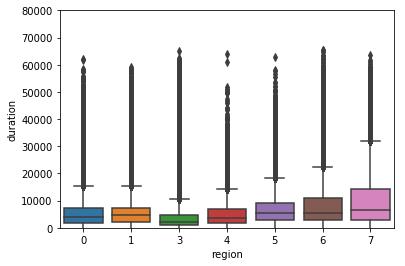

In [136]:
sns.boxplot(y='duration', x='region', data =time_meter)
plt.ylim(0, 80000)

(0, 80000)

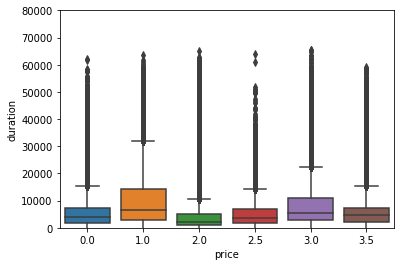

In [137]:
sns.boxplot(y='duration', x='price', data =time_meter)
plt.ylim(0, 80000)

In [216]:
#time_meter.groupby('OLD_RATE_AREA')['time_diff'].agg(lambda x: x.mean())

In [213]:
#total_record = time_meter.groupby('OLD_RATE_AREA').count()['post_id']
#total_meter = time_meter.groupby('OLD_RATE_AREA')['post_id'].nunique()
#total_record/total_meter

#### calculate pay rate

In [155]:
#time_meter['gross_paid_amt'].describe(),\
#time_meter['duration'].describe()
#import numpy as np
#np.percentile(time_meter['duration'], 1)

1800.0

In [13]:
time_meter_clean = time_meter[(time_meter['duration'] >= 240) & (time_meter['duration'] <= 8*3600)]
time_meter_clean = time_meter_clean[time_meter_clean['gross_paid_amt'] > 0]
time_meter_clean['hourly_rate'] = time_meter_clean['gross_paid_amt']/(time_meter_clean['duration']/3600)
time_meter_clean = time_meter_clean[time_meter_clean.gross_paid_amt >= 0.5]

In [23]:
time_meter_clean['gross_paid_amt'].sum()/366

72078.76696721312

In [192]:
time_meter_clean[['hourly_rate','duration']].corr()

,hourly_rate,duration
hourly_rate,1.000000,-0.225703
duration,-0.225703,1.000000


In [14]:
time_meter_clean.describe()

,index,gross_paid_amt,BLOCKFACE_ID,slot,stage,time_diff,duration,price,region,hourly_rate
count,1.021235e+07,1.021235e+07,1.021235e+07,1.021235e+07,1.021235e+07,10212350,1.021235e+07,1.021235e+07,1.021235e+07,1.021235e+07
mean,6.769092e+06,2.583228e+00,4.746450e+05,2.556694e+01,1.882052e+00,0 days 01:21:18.235674,4.878236e+03,1.930556e+00,2.707898e+00,2.175253e+00
std,4.104735e+06,2.771380e+00,1.811756e+05,5.451188e+00,1.984357e+00,0 days 01:12:35.110263,4.355110e+03,7.834659e-01,1.256570e+00,1.334516e+00
min,7.000000e+00,5.000000e-01,1.020210e+05,0.000000e+00,0.000000e+00,0 days 00:04:00,2.400000e+02,0.000000e+00,0.000000e+00,6.250000e-02
25%,3.121914e+06,7.500000e-01,3.521320e+05,2.100000e+01,0.000000e+00,0 days 00:30:00,1.800000e+03,2.000000e+00,3.000000e+00,1.409186e+00
50%,6.641524e+06,1.680000e+00,4.700810e+05,2.600000e+01,2.000000e+00,0 days 01:00:00,3.600000e+03,2.000000e+00,3.000000e+00,2.000000e+00
75%,1.042991e+07,3.500000e+00,6.121810e+05,3.000000e+01,3.000000e+00,0 days 02:00:00,7.200000e+03,2.000000e+00,3.000000e+00,2.707877e+00
max,1.379239e+07,5.600000e+01,8.780020e+05,4.500000e+01,6.000000e+00,0 days 08:00:00,2.880000e+04,3.500000e+00,7.000000e+00,6.398104e+01


In [15]:
time_meter_clean.to_csv('../../../time_meter_clean.csv')

#### 3) Continuous parking time model

In [16]:
X = pd.get_dummies(data = time_meter_clean.region, drop_first = True)
X['hourly_rate'] = time_meter_clean['hourly_rate']
Y = time_meter_clean['duration']

In [17]:
import pandas as pd
import numpy as np
from sklearn import datasets, linear_model
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy import stats

X2 = sm.add_constant(X)
est = sm.OLS(Y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:               duration   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                 2.044e+05
Date:                Wed, 16 Dec 2020   Prob (F-statistic):               0.00
Time:                        00:17:07   Log-Likelihood:            -9.9392e+07
No. Observations:            10212350   AIC:                         1.988e+08
Df Residuals:                10212342   BIC:                         1.988e+08
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        7820.5177      4.569   1711.689      

In [21]:
(Y-est2.predict(X2)).var()/3600/3600

1.2836783204353606

In [208]:
cont_model = linear_model.LinearRegression()
cont_model.fit(X,Y)

LinearRegression()

In [209]:
cont_model.coef_

array([ 1200.60713276, -1798.15308807,  -102.16784653,  1454.12437292,
        2164.02749974,  2935.83033254,  -820.36373099])

In [205]:
X.columns

Index([1, 3, 4, 5, 6, 7, 'hourly_rate'], dtype='object')